# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 2: сверточный классификатор.

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

Matplotlib created a temporary cache directory at /var/folders/6p/bshr1_dj3_7_gk1krflr4lzm0000gn/T/matplotlib-1tdp4mrq because the default path (/Users/dan/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда. 



In [5]:
def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [transforms.ToTensor(),
         # Переводим цвета пикселей в отрезок [-1, 1]
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )
    
    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)
    
    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(np.arange(len(trainvalset)), test_size=0.3, 
                                            shuffle=True, random_state=0)
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                              shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader
    

In [6]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, 
                                                         transform_train=transform)

Files already downloaded and verified
Files already downloaded and verified


Посмотрим на изображения:

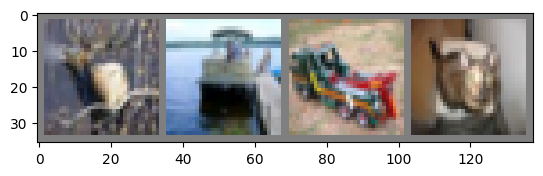

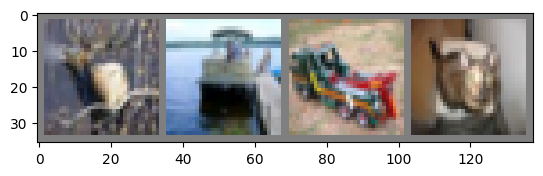

deer ship truck cat


In [7]:
def imshow(img):
    img = img / 2 + 0.5    
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
# images, labels = dataiter.next()

for images, labels in train_loader:
    imshow(torchvision.utils.make_grid(images[:4]))
    break


imshow(torchvision.utils.make_grid(images[:4]))

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры ResNet.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [8]:
class BasicBlockNet(nn.Module):
    def __init__(self):
        super().__init__()
        n_classes = 10

        # Определение первого блока слоев (до входа skip connection)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32)
        )
        
        # Определение второго блока слоев (после входа skip connection)
        self.block2 = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=8, stride=8), # [32x4x4]
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, n_classes)#, 
        #    nn.Softmax(dim=1)
        )

        # 1x1 слой свертки данных, передаваемых через skip connection
        self.skip_connection = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        # Прямой проход через первый блок слоев
        out = self.block1(x)

        # Добавляем значение из skip connection к выходу второго блока слоев
        x_skip_connection = self.skip_connection(x)
        out += x_skip_connection

        # Прямой проход через второй блок слоев
        logits = self.block2(out)

        return logits


In [130]:
# My test
model = BasicBlockNet()
input_tensor = torch.randn(3, 3, 32, 32)  # Пример входного тензора
# print(input_tensor.shape)
output = model(input_tensor)
print(output.shape)

torch.Size([3, 10])


In [131]:
net = BasicBlockNet()
net

BasicBlockNet(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): Sequential(
    (0): ReLU(inplace=True)
    (1): AvgPool2d(kernel_size=8, stride=8, padding=0)
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
  (skip_connection): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
)

Проверим, что выход сети имеет корректную размерность:

In [133]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [134]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [ ]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [9]:
def test(model, loader, criterion = nn.CrossEntropyLoss()):
    loss_log = []
    acc_log = []
    model.eval()
    
    for data, target in loader:
        
        with torch.no_grad():
            # Прямой проход и вектор пердсказаний
            logits = model(data)

            loss = criterion(logits, target)

        # Loss & eval metric    
        loss_log.append(loss.item())
                        
        acc = np.mean((logits.argmax(dim=1) == target).cpu().numpy()) # Тут кол-во правильных ответов 
        acc_log.append(acc) 

    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader, criterion = nn.CrossEntropyLoss()):
    loss_log = []
    acc_log = []
    model.train()
    
    for data, target in train_loader:
        # Заниляем гралиенты
        optimizer.zero_grad()

        # Прямой проход и вектор пердсказаний
        logits = model(data)

        # Оценка потерь
        loss = criterion(logits, target)
        loss_log.append(loss.item())

        # Проход назад и шаг sgd
        loss.backward()
        optimizer.step()
        
        # Accuracy
        acc = np.mean((logits.argmax(dim=1) == target).cpu().numpy())  # np array в формате ([True, False, False, True]) [1*batch_size]
        acc_log.append(acc) 


    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in tqdm(range(n_epochs), 'epoch:'):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)
        
        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)
        
        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")
        
        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

Посчитайте точность на тестовой выборке:

In [193]:
net = BasicBlockNet()

optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler=None)


# Точность на тесте
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5204847878904186, train acc: 0.45776475581091675
 val loss: 1.2999873019279318, val acc: 0.5313829787234042

Epoch 1
 train loss: 1.2118005073702531, train acc: 0.5732567249934708
 val loss: 1.1783145869031866, val acc: 0.5866799645390072

Epoch 2
 train loss: 1.0729453457992735, train acc: 0.6266771676677984
 val loss: 1.0706332658199553, val acc: 0.6277925531914894

Epoch 3
 train loss: 1.006728649030438, train acc: 0.6464563201880386
 val loss: 1.0165291134347307, val acc: 0.6492907801418439

Epoch 4
 train loss: 0.9668351301763349, train acc: 0.6650031013319405
 val loss: 1.0230634220103, val acc: 0.6495567375886524

Epoch 5
 train loss: 0.9336382260706133, train acc: 0.6745111321493863
 val loss: 0.9808522528790413, val acc: 0.6591090425531915

Epoch 6
 train loss: 0.9100597711106323, train acc: 0.6839049033690258
 val loss: 0.9402275889477831, val acc: 0.6711879432624114

Epoch 7
 train loss: 0.8853766025747198, train acc: 0.6926171977017498
 val loss: 0.97

In [196]:
# Точность на тесте 0.6994426751592356

Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

In [197]:
len(train_loss_log), len(train_acc_log), len(val_loss_log), len(val_acc_log)

(10940, 10940, 20, 20)

In [205]:
# Соберем значения по оси X - номер эпохи
epoch_size = int(10940 / 20)

x_train_plt = [x for x in range(len(train_loss_log))]  
x_val_plt= [x * epoch_size for x in range(len(val_loss_log))]  

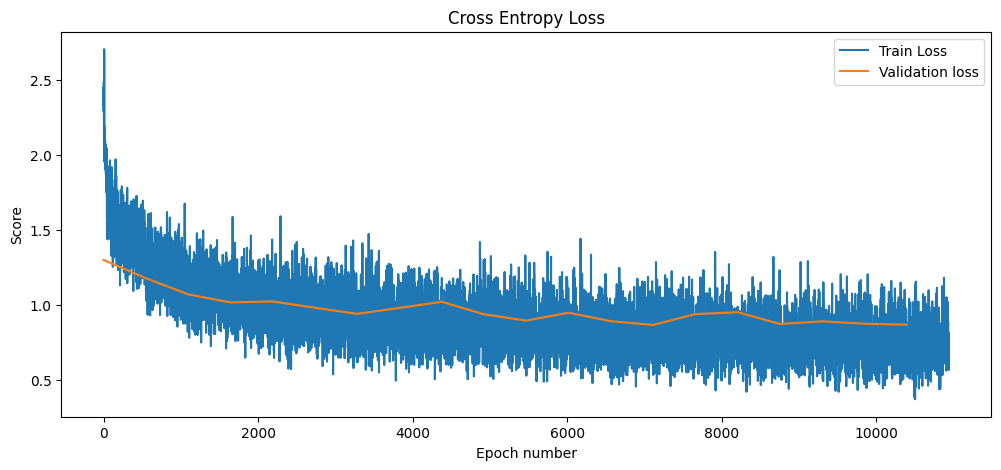

In [206]:
plt.figure(figsize=(12,5))

plt.plot(x_train_plt, train_loss_log, label='Train Loss')
plt.plot(x_val_plt, val_loss_log, label='Validation loss')

plt.xlabel('Epoch number')
plt.ylabel('Score')
plt.title('Cross Entropy Loss')

plt.legend()

plt.show()

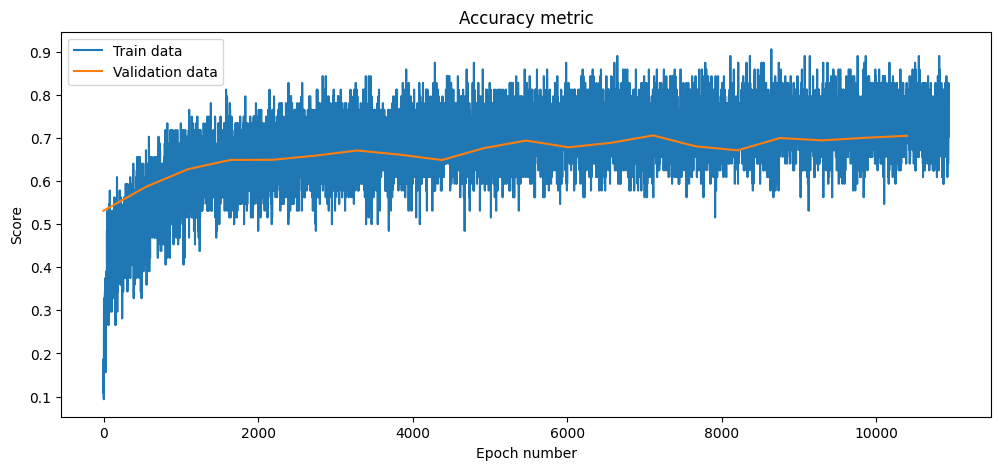

In [207]:
plt.figure(figsize=(12,5))

plt.plot(x_train_plt, train_acc_log, label='Train data')
plt.plot(x_val_plt, val_acc_log, label='Validation data')

plt.xlabel('Epoch number')
plt.ylabel('Score')
plt.title('Accuracy metric')

plt.legend()

plt.show()

___Дополнительные графики по эпохам___

In [208]:
# Усредню логи функции потерь и качества классификации в рамках эпохи (10940 значений >> 20)

# В каждой эпохе лежит 10940 / 20 значений
epoch_size = int(10940 / 20)
split_len_old = 0
split_len = epoch_size

# тут будем хранить усредненные метрики по эпохам
train_loss_log_batch = list()
train_acc_log_batch =list()


for _ in range(20):
    
    # Данные за эпоху
    loss_values = train_loss_log[split_len_old:split_len]
    acc_values = train_acc_log[split_len_old:split_len]

    # Првоерим достаточно ли данных в срезе
    assert len(acc_values) == len(loss_values) == epoch_size, 'len of list with values != len batch size'

    # Добавим усредненные метрики
    train_loss_log_batch.append(np.mean(loss_values))
    train_acc_log_batch.append(np.mean(acc_values))

    # шаг на новую эполху
    split_len_old = split_len_old + epoch_size
    split_len = split_len + epoch_size

len(train_loss_log_batch), len(train_acc_log_batch)

(20, 20)

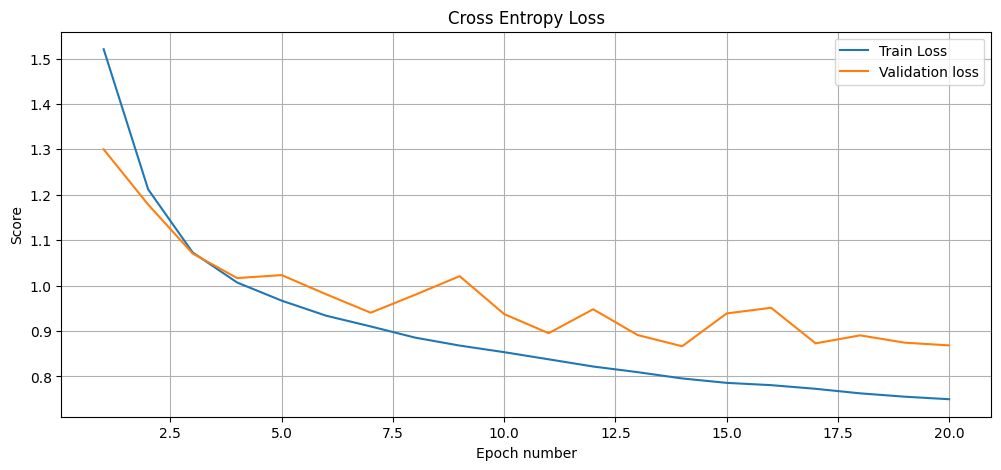

In [209]:
plt.figure(figsize=(12,5))

# Значения по оси X - номер эпохи
list_x = [x+1 for x in range(20)]  

plt.plot(list_x, train_loss_log_batch, label='Train Loss')
plt.plot(list_x, val_loss_log, label='Validation loss')

plt.xlabel('Epoch number')
plt.ylabel('Score')
plt.title('Cross Entropy Loss')

plt.legend()
plt.grid()

plt.show()


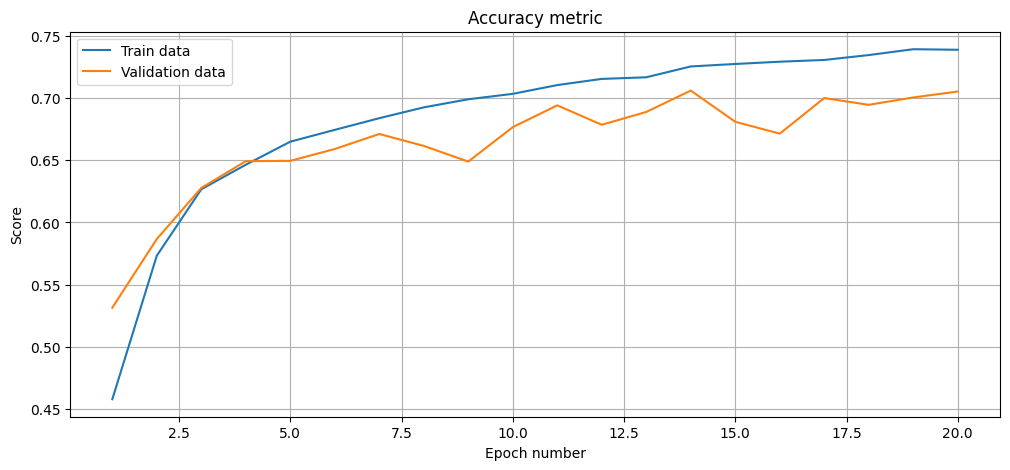

In [210]:
plt.figure(figsize=(12,5))

# Значения по оси X - номер эпохи
list_x = [x+1 for x in range(20)]  

plt.plot(list_x, train_acc_log_batch, label='Train data')
plt.plot(list_x, val_acc_log, label='Validation data')

plt.xlabel('Epoch number')
plt.ylabel('Score')
plt.title('Accuracy metric')

plt.legend()
plt.grid()


plt.show()

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [180]:
net = BasicBlockNet() #.to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.4817623606111712, train acc: 0.47022313267171584
 val loss: 1.3833998421405225, val acc: 0.5220079787234042

Epoch 1
 train loss: 1.1748695201368176, train acc: 0.589779478976234
 val loss: 1.1322772578990206, val acc: 0.6070478723404256

Epoch 2
 train loss: 1.0577428287518307, train acc: 0.6313250848785584
 val loss: 1.05548225057886, val acc: 0.6331117021276595

Epoch 3
 train loss: 1.0049538627621024, train acc: 0.6524794332723949
 val loss: 1.0486522458969278, val acc: 0.6337987588652482

Epoch 4
 train loss: 0.964971050483871, train acc: 0.6678147035779578
 val loss: 0.9931082535297313, val acc: 0.6581117021276596

Epoch 5
 train loss: 0.9363479013852707, train acc: 0.6747967811439017
 val loss: 0.9425122451274953, val acc: 0.6754210992907801

Epoch 6
 train loss: 0.9183710683852271, train acc: 0.6840599699660486
 val loss: 1.0211953792166202, val acc: 0.6495124113475178

Epoch 7
 train loss: 0.8865151045200376, train acc: 0.6937638743797336
 val loss: 0.97

Посчитайте точность на тестовой выборке:

In [181]:
loss_log, acc_log = test(net, test_loader)

In [183]:
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.824096637926284
Accuracy on test: 0.7177547770700637


**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [184]:
net = BasicBlockNet() #.to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)

epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.7910177363338156, train acc: 0.3675404805432228
 val loss: 1.5688851676088698, val acc: 0.4530806737588653

Epoch 1
 train loss: 1.4982394189241817, train acc: 0.47190030033951424
 val loss: 1.4258713032336945, val acc: 0.4988696808510638

Epoch 2
 train loss: 1.3887092029808643, train acc: 0.5132581940454426
 val loss: 1.347143369532646, val acc: 0.5283244680851064

Epoch 3
 train loss: 1.3283013846364273, train acc: 0.5335025463567512
 val loss: 1.295359081410347, val acc: 0.549002659574468

Epoch 4
 train loss: 1.275872984250677, train acc: 0.5556525855314703
 val loss: 1.2519485851551624, val acc: 0.5660239361702127

Epoch 5
 train loss: 1.2322602423497049, train acc: 0.5707756594411073
 val loss: 1.2158422538574705, val acc: 0.5721631205673758

Epoch 6
 train loss: 1.190793125132538, train acc: 0.5855273896578741
 val loss: 1.1662268737529187, val acc: 0.5887411347517731

Epoch 7
 train loss: 1.153099945193017, train acc: 0.5996425306868634
 val loss: 1.1276

In [185]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.9597541109012191
Accuracy on test: 0.6700835987261147


**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

___CosineAnnealingLR___

In [186]:
net = BasicBlockNet() #.to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

# T_max: количество эпох для одного цикла снижения LR (Если эпох больше - lr начнет увеличиваться)
# eta_min: - минимально допустимый learning rate
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=0.0001)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5023396552371804, train acc: 0.46630974144685294
 val loss: 1.3131587178149122, val acc: 0.5347074468085107

Epoch 1
 train loss: 1.187237956297245, train acc: 0.5819975842256464
 val loss: 1.09448757475995, val acc: 0.620811170212766

Epoch 2
 train loss: 1.0636688165734411, train acc: 0.6279340232436668
 val loss: 1.1081292352777847, val acc: 0.6042109929078013

Epoch 3
 train loss: 1.0007701157651827, train acc: 0.652373335074432
 val loss: 0.9950973117605169, val acc: 0.6525044326241135

Epoch 4
 train loss: 0.9636696217482879, train acc: 0.6652152977278664
 val loss: 0.9820218253642955, val acc: 0.6628767730496454

Epoch 5
 train loss: 0.9265706240585997, train acc: 0.6768126469051973
 val loss: 0.9368010424553079, val acc: 0.6734264184397162

Epoch 6
 train loss: 0.9053347094948156, train acc: 0.6834805105771742
 val loss: 0.9679108424389616, val acc: 0.6629432624113476

Epoch 7
 train loss: 0.8762573327399259, train acc: 0.6937924392791851
 val loss: 0.921

In [187]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.829855830236605
Accuracy on test: 0.7185509554140127


___ReduceLROnPlateau___

In [ ]:
# net = BasicBlockNet() #.to(device)
# optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

# mode: уменьшаем скорость обучения, когда метрика не улучшается
# factor: lr_new = factor * lr_old коэфицент, влияющией на изменение lr
# patience: количество эпох без улучшения, после которых скорость обучения будет уменьшена
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

___LambdaLR___

In [189]:
net = BasicBlockNet() #.to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)

# Лямбда-функция для изменения скорости обучения
lambda1 = lambda epoch: 0.9 ** epoch

# Scheduler
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.4633205193052343, train acc: 0.4780131888221468
 val loss: 1.262495065242686, val acc: 0.5580452127659574

Epoch 1
 train loss: 1.1400347563422795, train acc: 0.6021235962392268
 val loss: 1.1127267122268676, val acc: 0.6152260638297873

Epoch 2
 train loss: 1.0450075799412004, train acc: 0.6377032188560983
 val loss: 1.0518717469053065, val acc: 0.6345301418439715

Epoch 3
 train loss: 0.982947629701067, train acc: 0.6579557325672499
 val loss: 1.0216969682815227, val acc: 0.6398492907801417

Epoch 4
 train loss: 0.9404050767748622, train acc: 0.6742499673544006
 val loss: 0.9543080154885637, val acc: 0.6687056737588651

Epoch 5
 train loss: 0.904768392089516, train acc: 0.6874102246017237
 val loss: 0.9116340515461374, val acc: 0.6890292553191489

Epoch 6
 train loss: 0.8801616873776019, train acc: 0.696106196134761
 val loss: 0.9471158560286177, val acc: 0.6703457446808511

Epoch 7
 train loss: 0.8510547901420314, train acc: 0.7050266061634891
 val loss: 0.895

In [190]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.8669429713753378
Accuracy on test: 0.6988455414012739


___CosineAnnealingLR___

В алгоритме CosineAnnealingLR используется график косинусного отжига, сам алгоритм зависит от следующих параметров:
1) Стартовый LR
2) Минимальный LR
3) Количество эпох для одного цикла снижения LR

Стартуя с заданного LR алгоритм снижает его на каждой эпохе. LR уменьшается наиболее быстро в начале и конце каждого цикла. Если кол-во эпох алгоритма = кол-ву эпох в одном цикле для шедулера - мы остановимся на самом минимальном LR, который задан как гиперпараметр. Если шагов алгоритма больше, чем в цикле шедулера - LR начнет расти, после того как дойдет до минимума и тд. Если шагов алгоритма ментше - мы не дойдем до заданного минимума. 


___ReduceLROnPlateau___

Мне понравилась идея данного метода, но она потребовала внесения доработак в скрипт обучения модели, поэтому я не до конца реализовал алгоритм с этим шедулером.

Шедулер динамически изменяет скорость обучения, триггером для этого является изменения метрики обучения - если метрика не улучшается, то скорость обучения меняется. То есть шедулер отслеживает заданную метрику в optimizer. Если метрика не улучшается в течении заданного кол-ва эпох, то LR уменьшается. Шедулер настраивается несколькими параметрами

1) mode: При аргументе 'min' - уменьшаем скорость обучения, когда метрика не улучшается
2) factor: коэфицент, влияющией на изменение lr, пример: lr_new = factor * lr_old 
3) patience: количество эпох без улучшения, после которых скорость обучения будет уменьшена

___LambdaLR___

Этот шедулер позволяет самостоятельно реализовать лямбда-функцию, которая будет определять как будет меняться LR. В моем примере скорость обучения падала на 10% на каждой эпохе

In [218]:
# Пример скорости уменьшения LR
i = 0.1
print('step: lr')
for j in range(20):
    print(f'{j}: {round(i,5)}')
    i = i * 0.9

step: lr
0: 0.1
1: 0.09
2: 0.081
3: 0.0729
4: 0.06561
5: 0.05905
6: 0.05314
7: 0.04783
8: 0.04305
9: 0.03874
10: 0.03487
11: 0.03138
12: 0.02824
13: 0.02542
14: 0.02288
15: 0.02059
16: 0.01853
17: 0.01668
18: 0.01501
19: 0.01351


<!--  -->

<!--  -->

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

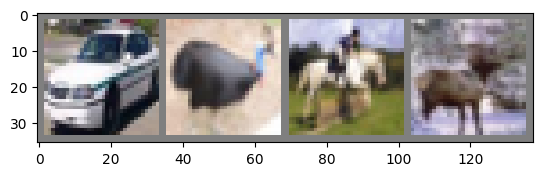

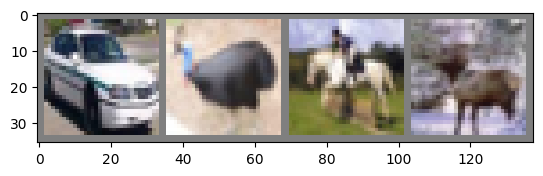

In [220]:
dataiter = iter(train_loader)

# images, labels = dataiter.next()
# imshow(torchvision.utils.make_grid(images[:4]))

for images, labels in train_loader:
    break

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [27]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Files already downloaded and verified
Files already downloaded and verified


epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.4572166572759095, train acc: 0.4817878362496736
 val loss: 1.2535712962454937, val acc: 0.5474734042553191

Epoch 1
 train loss: 1.1513130383692014, train acc: 0.5967737986419431
 val loss: 1.1090920488885108, val acc: 0.6111258865248226

Epoch 2
 train loss: 1.0448036221089267, train acc: 0.6361362300861845
 val loss: 1.003024481458867, val acc: 0.6522606382978723

Epoch 3
 train loss: 0.9934042910117336, train acc: 0.6563887437973361
 val loss: 0.993694698049667, val acc: 0.6595744680851063

Epoch 4
 train loss: 0.9610116730224498, train acc: 0.6684023243666753
 val loss: 1.01731779803621, val acc: 0.6468085106382979

Epoch 5
 train loss: 0.9264386153526236, train acc: 0.677551253591016
 val loss: 0.9399219368366485, val acc: 0.6755762411347519

Epoch 6
 train loss: 0.9075887337245279, train acc: 0.6873612562026639
 val loss: 0.987938790879351, val acc: 0.657424645390071

Epoch 7
 train loss: 0.8966959457728719, train acc: 0.6888262274745365
 val loss: 0.884231

Посчитайте точность на тестовой выборке:

In [222]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.7962845180444657
Accuracy on test: 0.7241242038216561


**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

___ColorJitter___

Эта трансформация добавляет случайные изменения яркости, контраста, насыщенности и оттенка к изображению. 
Данные модификации направлены на улучшение возможности модели обобщать.

ColorJitter содерит следующие настройки:
1) brightness - контроль яркости изображения.
2) contrast - контроль контраста изображения. 
3) saturation - контроль насыщенности изображения. 
4) hue - контроль оттенка изображения. 

Для каждого параметра я передаю значения 0.1 - это значит, что каждый параметр будем меняться на +/-10% относительно исходной картинки. Если параметр равен 0 -> изменений не будет. Чем больше задается параметр - тем сильнее меняются изображения.

In [13]:
# Определяем трансформации
transform = transforms.Compose(
        [transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Files already downloaded and verified
Files already downloaded and verified


epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.4991991911117513, train acc: 0.4698721924784539
 val loss: 1.2561859508778186, val acc: 0.5548758865248226

Epoch 1
 train loss: 1.187584915043449, train acc: 0.5864414664403238
 val loss: 1.1155102897197642, val acc: 0.6103501773049647

Epoch 2
 train loss: 1.0892886870304017, train acc: 0.6219721206581352
 val loss: 1.0575104736267251, val acc: 0.6393617021276595

Epoch 3
 train loss: 1.0303151712121215, train acc: 0.6421307782710891
 val loss: 1.0339566096346429, val acc: 0.6459441489361702

Epoch 4
 train loss: 0.9892551897866635, train acc: 0.6609876926090363
 val loss: 1.049583359982105, val acc: 0.6372562056737587

Epoch 5
 train loss: 0.9565554206724358, train acc: 0.6696836641420736
 val loss: 1.00572681503093, val acc: 0.6539450354609928

Epoch 6
 train loss: 0.9303794615447413, train acc: 0.6807056346304518
 val loss: 0.9614002828902387, val acc: 0.6679299645390072

Epoch 7
 train loss: 0.9125898998005952, train acc: 0.683166296683207
 val loss: 0.9309

In [14]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.8299544894011917
Accuracy on test: 0.7209394904458599


Качество модели выше, если сравнивать модели обученной без аугментации:
 * Без аугментации: 0.7177547770700637
 * С ColorJitter аугментацией: 0.7209394904458599

 Но ниже, если сравнивать с RandomHorizontalFlip, ColorFetter меньшее качество:
 * 0.7241242038216561


<!--  -->

<!--  -->

___GaussianBlur___

Метод применяется для размытия исходного изображения, путем применения фильтра Гауса. Это в свою очередь уменьшает высокие частоты в изображении, в результате уменьшается уровень шума.

Гаусово размытие имеет 2 гиперпараметра:
1) kernel_size - размер ядра размытия
2) sigma - стандартное отклонение распределения Гаусса (контроль над степенью размытия)

In [16]:
transform = transforms.Compose(
        [transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Files already downloaded and verified
Files already downloaded and verified


epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5826159499898906, train acc: 0.4368307652128493
 val loss: 1.4699364073733066, val acc: 0.4805186170212766

Epoch 1
 train loss: 1.3249211913924765, train acc: 0.5285648994515539
 val loss: 1.2305233014390824, val acc: 0.5642287234042553

Epoch 2
 train loss: 1.2445889989244436, train acc: 0.5614226952206842
 val loss: 1.2711454673016325, val acc: 0.5585771276595745

Epoch 3
 train loss: 1.1948788523456078, train acc: 0.5783616805954557
 val loss: 1.1663706094660657, val acc: 0.5916666666666668

Epoch 4
 train loss: 1.1600707694207075, train acc: 0.5940560524941239
 val loss: 1.161548765162204, val acc: 0.5949024822695035

Epoch 5
 train loss: 1.1339324162472755, train acc: 0.598912085400888
 val loss: 1.1781761674170799, val acc: 0.5833998226950354

Epoch 6
 train loss: 1.1195893180871577, train acc: 0.6043149320971534
 val loss: 1.1353333917069943, val acc: 0.5979831560283688

Epoch 7
 train loss: 1.1046982926250157, train acc: 0.6117009989553408
 val loss: 1.1

In [18]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.9862129980591452
Accuracy on test: 0.660031847133758


Качество значительно ниже любых других подходов к обучению, используемых ранее в ноутбуке:
 * Без аугментации: 0.7177547770700637
 * С GaussianBlur аугментацией: 0.660031847133758


<!--  -->

<!--  -->

___RandomAffine___

Случайное аффинное преобразование - подвергает изображение различными геометрическим преобразованиям.

Параметры:
1) degrees: Диапазон углов поворота вокруг центра изображения
2) translate: Смещения изображения вдоль осей. 0.1 >> смещение на 10%
3) scale: Интервал масштабирования. 0.8, 1.2 >> Изображение становится меньше маштабом на 20% или больше на 20%
4) Максимальное значение деформации. 10 >> изображение может быть деформировано с углом скола до 10 градусов.

Применения указанных изменений позволяют построить модель более устойчивой к изменениям в позиции, размере и ориентации объектов в новых данных.

In [21]:
transform = transforms.Compose(
        [transforms.RandomAffine(degrees=(-15, 15), translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Files already downloaded and verified
Files already downloaded and verified


epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.7289322337895032, train acc: 0.3754651997910681
 val loss: 1.6006682096643652, val acc: 0.4196143617021277

Epoch 1
 train loss: 1.5310512347456742, train acc: 0.44814654609558635
 val loss: 1.462515255745421, val acc: 0.47511081560283686

Epoch 2
 train loss: 1.4345204278799473, train acc: 0.4888964155131888
 val loss: 1.3816296983272471, val acc: 0.5063164893617021

Epoch 3
 train loss: 1.369232036295931, train acc: 0.5072962914599113
 val loss: 1.3892236009557197, val acc: 0.5125

Epoch 4
 train loss: 1.3226817284031367, train acc: 0.527512078871768
 val loss: 1.323975020012957, val acc: 0.5214539007092199

Epoch 5
 train loss: 1.2839055003588118, train acc: 0.542928963175764
 val loss: 1.2765163974559053, val acc: 0.54729609929078

Epoch 6
 train loss: 1.2629195969327058, train acc: 0.5524165904936015
 val loss: 1.2613700582626017, val acc: 0.5526374113475178

Epoch 7
 train loss: 1.241503850633527, train acc: 0.5578153564899452
 val loss: 1.230762745471711, 

In [22]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.92258258420191
Accuracy on test: 0.681031050955414


Качество модели так же сильно ухудшилось:
 * Без аугментации: 0.7177547770700637
 * С RandomAffine аугментацией: 0.681031050955414


<!--  -->

<!--  -->

___Все преобразования вместе___

In [23]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)),
         transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
         transforms.RandomAffine(degrees=(-15, 15), translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Files already downloaded and verified
Files already downloaded and verified


epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.7869433358556828, train acc: 0.35456793549229565
 val loss: 1.6457314095598585, val acc: 0.3983377659574468

Epoch 1
 train loss: 1.6133676185468433, train acc: 0.41742703708540085
 val loss: 1.5524908223050706, val acc: 0.44461436170212765

Epoch 2
 train loss: 1.532396883589694, train acc: 0.44912999477670407
 val loss: 1.4628939897456068, val acc: 0.4783687943262411

Epoch 3
 train loss: 1.4840006172330114, train acc: 0.46782776181770697
 val loss: 1.440284322170501, val acc: 0.4807845744680851

Epoch 4
 train loss: 1.4317458392933038, train acc: 0.48777422303473494
 val loss: 1.41834876537323, val acc: 0.491156914893617

Epoch 5
 train loss: 1.4085792648508955, train acc: 0.49803718333768604
 val loss: 1.4264280415595847, val acc: 0.4910682624113475

Epoch 6
 train loss: 1.3942753999499125, train acc: 0.5030319600417863
 val loss: 1.3545936396781435, val acc: 0.5161790780141844

Epoch 7
 train loss: 1.3849782115580613, train acc: 0.5054314115957168
 val loss:

In [24]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 1.0488704010179848
Accuracy on test: 0.6357484076433121


До этого момента самый худший подход был в использовании GaussianBlur, но на данном этапе получилось еще более худшее качество:
 * Без аугментации: 0.7177547770700637
 * С GaussianBlur аугментацией: 0.660031847133758
 * Все используемые методы: 0.6357484076433121

<!--  -->

<!--  -->

___Только лучшие преобразования___

In [25]:
# Определяем трансформации
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Files already downloaded and verified
Files already downloaded and verified


epoch::   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5063846780351573, train acc: 0.46552624706189605
 val loss: 1.317302301335842, val acc: 0.5342641843971631

Epoch 1
 train loss: 1.1911387614619797, train acc: 0.5832136328022982
 val loss: 1.1174782441017475, val acc: 0.610793439716312

Epoch 2
 train loss: 1.0786079100760506, train acc: 0.6239308566205275
 val loss: 1.0750128748569083, val acc: 0.6276152482269503

Epoch 3
 train loss: 1.0314266818968862, train acc: 0.6407433402977278
 val loss: 1.0142016136899907, val acc: 0.648825354609929

Epoch 4
 train loss: 0.9938011982323265, train acc: 0.655760316009402
 val loss: 1.0298156269053196, val acc: 0.6422872340425532

Epoch 5
 train loss: 0.9669233965917304, train acc: 0.6660763254113345
 val loss: 0.9814779644316816, val acc: 0.6538120567375886

Epoch 6
 train loss: 0.9525821700392519, train acc: 0.6716791264037607
 val loss: 1.0054575111003632, val acc: 0.6485372340425531

Epoch 7
 train loss: 0.9396135661567151, train acc: 0.6745682619482893
 val loss: 0.97

In [26]:
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.8201810077876802
Accuracy on test: 0.7179538216560509


Качество модели выше (незначистельно), если сравнивать модели обученной без аугментации, но ниже чем с RandomHorizontalFlip:
* RandomHorizontalFlip: 0.7241242038216561
* С ColorJitter аугментацией: 0.7209394904458599
* С топ2 видами аугментации: 0.7179538216560509
* Без аугментации: 0.7177547770700637
 
 

 
 


<!--  -->

<!--  -->

## Бонус. Логирование в wandb (2 балла)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. Вероятно, самый популярный из них — [wandb](https://wandb.ai/site).

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо через wandb логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код и публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2.

___Настройка wandb___

In [1]:
import wandb
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: dangennadevich (HSE_IUGAI). Use `wandb login --relogin` to force relogin


True

In [3]:
# Инициализация wandb
run = wandb.init(
    project="my-awesome-project",
    config={
        "learning_rate": 0.1,
        "epochs": 20,
    },
)

___Добавление кодя для логирования___

In [11]:
def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in tqdm(range(n_epochs), 'epoch:'):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)
        
        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)
        
        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        # Логирование метрик в wandb
        wandb.log({
            "Train Loss": np.mean(train_loss),
            "Train Acc": np.mean(train_acc),
            "Val Loss": val_loss,
            "Val Acc": val_acc
        })

        # print(f"Epoch {epoch}")
        # print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        # print(f" val loss: {val_loss}, val acc: {val_acc}\n")
        
        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

___Обучение модели с лгирование на wandb___

In [12]:
net = BasicBlockNet()

optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler=None)

epoch::   0%|          | 0/20 [00:00<?, ?it/s]

In [13]:
# Точность на тесте
loss_log, acc_log = test(net, test_loader)
print(f'Loss on test: {loss_log}\nAccuracy on test: {acc_log}')

Loss on test: 0.8835146730872476
Accuracy on test: 0.6962579617834395


Мой отчет находится тут:

https://api.wandb.ai/links/HSE_IUGAI/7at2khra